# Text Normalization & Dataset Preparation for Fine-Tuning
**Project:** KCMS (Khmer Comment Moderation System)  
**Task:** Text Normalization, Preprocessing & Dataset Construction  
**Model Target:** XLM-RoBERTa (`xlm-roberta-base`) Multi-Task Classifier  

---

### Objectives
1. **Standardize Khmer Orthography:** Normalize decomposed vowel sequences (e.g. `\u17C1\u17B8` -> `\u17BE` "មើល") and deduplicate stacked diacritics.
2. **Eliminate Invisible Noise:** Clean Zero-Width Spaces (`\u200b`), ZWNJs, ZWJs, and BOM markers that break tokenizers.
3. **Handle Social Media Noise:** Neutralize URLs with `[URL]` tokens, record `link_flagged` metadata, and cap character/emoji elongations.
4. **Sequence Length Diagnostics:** Determine optimal `max_length` for transformer tokenization.
5. **KCMS AI Engine Integration:** Export clean datasets matching the schema expected by `ai_engine/src/dataset.py`.


## 1. Environment Setup & Configuration
We load standard data processing libraries and configure reproducibility seeds.


In [1]:
import os
import sys
import re
import html
import unicodedata
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visual styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Khmer OS", "Noto Sans Khmer", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("Environment configured successfully. Pandas version:", pd.__version__)


Environment configured successfully. Pandas version: 2.3.3


## 2. Load and Inspect Raw Comments Data
We load the raw scraped Facebook comments from `scraper/raw_data/comments.csv` and inspect the initial structure.


In [2]:
# Locate comments.csv whether run from notebook directory or workspace root
curr_dir = Path.cwd()
possible_paths = [
    curr_dir.parent / "raw_data" / "comments.csv",
    curr_dir / "scraper" / "raw_data" / "comments.csv",
    Path("/Users/oudommengbycha/project/detect_comment/scraper/raw_data/comments.csv")
]

raw_csv_path = next((p for p in possible_paths if p.exists()), None)
if not raw_csv_path:
    raise FileNotFoundError("Could not find raw comments.csv")

raw_df = pd.read_csv(raw_csv_path)
print(f"Loaded raw dataset with {len(raw_df)} rows and {len(raw_df.columns)} columns.")
print("Columns:", list(raw_df.columns))

# Display top 5 sample comments
raw_df[["comment_id", "text", "is_reply"]].head(5)


Loaded raw dataset with 994 rows and 14 columns.
Columns: ['comment_id', 'text', 'severity_id', 'target_id', 'has_pii', 'link_flagged', 'annotator', 'split', 'notes', 'post_text', 'parent_text', 'is_reply', 'created_time', 'source_page_id']


,comment_id,text,is_reply
0,dom__0,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ​ អាចចូលតាមលីងខាងក្រោ...,False
1,dom__1,អូខេ អ្នកឈ្នះ,False
2,dom__2,កូនខ្មែរម្នាក់ទៀតហើយ...,False
3,dom__3,ឃើញតាំង ចាស់ណាវ តែទើបដាច់ចិត្តបញ្ចេញមតិ loy na...,False
4,dom_Ngngengrk_4,"Ng ng , eng rk ah ng heee",False


## 3. Raw Data Noise & Orthography Diagnostics
Social media comments contain significant noise. We inspect specific anomalies:
- **Invisible Zero-Width Space (\u200b)**: In Khmer mobile typing, ZWSP is used irregularly. When fed to SentencePiece / BPE tokenizers, it creates unknown tokens or fragments common words.
- **Decomposed Split Vowels**: In Khmer Unicode, typing Sara E (`\u17C1`) + Sara I (`\u17B8`) instead of precomposed Sara OE (`\u17BE`) creates vocabulary mismatch.
- **URLs / External Links**: Spam or promotion links that should be flagged and normalized.
- **Character / Emoji Elongation**: Repetitive characters like "ណាស់សសសស" or "heee" and repeated emojis.
- **Duplicate Rows**: Scraped duplicate comments.


In [3]:
texts = raw_df["text"].dropna().astype(str).tolist()

zwsp_count = sum(1 for t in texts if "\u200b" in t)
url_count = sum(1 for t in texts if re.search(r"https?://\S+|www\.\S+", t))
repeated_chars_count = sum(1 for t in texts if re.search(r"(.)\1{3,}", t))
split_vowel_count = sum(1 for t in texts if "\u17C1\u17B8" in t or "\u17C1\u17B6" in t)
exact_duplicates = raw_df["text"].duplicated().sum()

diag_summary = pd.DataFrame([
    {"Issue": "Exact Duplicate Comments", "Affected Rows": exact_duplicates, "NLP Risk": "Data leakage across train/eval splits"},
    {"Issue": "Invisible Zero-Width Space (\u200b)", "Affected Rows": zwsp_count, "NLP Risk": "Tokenizer vocabulary fragmentation / <unk>"},
    {"Issue": "Decomposed Split Vowels (e.g. មេីល vs មើល)", "Affected Rows": split_vowel_count, "NLP Risk": "Mismatched subword embeddings"},
    {"Issue": "Social Media URLs (Telegram, YouTube, TikTok)", "Affected Rows": url_count, "NLP Risk": "Spam noise; needs link_flagged=True"},
    {"Issue": "Elongated Characters / Emojis (3+ repeats)", "Affected Rows": repeated_chars_count, "NLP Risk": "Out-of-vocabulary explosion"},
])
diag_summary


,Issue,Affected Rows,NLP Risk
0,Exact Duplicate Comments,10,Data leakage across train/eval splits
1,Invisible Zero-Width Space (​),20,Tokenizer vocabulary fragmentation / <unk>
2,Decomposed Split Vowels (e.g. មេីល vs មើល),39,Mismatched subword embeddings
3,"Social Media URLs (Telegram, YouTube, TikTok)",3,Spam noise; needs link_flagged=True
4,Elongated Characters / Emojis (3+ repeats),8,Out-of-vocabulary explosion


## 4. Khmer & Multilingual Normalization Engine
We define modular normalization functions adhering to standard NLP best practices:
1. `normalize_unicode`: HTML unescape and Unicode NFC canonical composition.
2. `normalize_khmer_vowels`: Precomposes split vowels and removes duplicate stacked diacritics.
3. `clean_invisible_chars`: Converts ZWSP, ZWNJ, and BOM markers to single spaces.
4. `normalize_elongation`: Caps repeated letters, vowels, and emojis to a maximum of 2.
5. `clean_urls`: Replaces URLs with `[URL]` and flags link presence.
6. `normalize_whitespace`: Collapses multiple spaces, tabs, and newlines into single spaces.


In [4]:
# Regex patterns for normalization
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
ZWSP_PATTERN = re.compile(r"[\u200b\u200c\u200d\ufeff\u200e\u200f]+")
WHITESPACE_PATTERN = re.compile(r"[\s\u00a0\u3000]+")
REPEATED_CHARS_PATTERN = re.compile(r"(.)\1{2,}")
REPEATED_KHMER_DIACRITICS = re.compile(r"([\u17B6-\u17D3])\1+")

# Khmer Vowel Composition Mapping (decomposed -> canonical precomposed)
KHMER_VOWEL_REPLACEMENTS = [
    ("\u17C1\u17B6", "\u17C4"),  # Sara E + Sara AA -> Sara OO (ស្រៈអោ)
    ("\u17C1\u17B8", "\u17BE"),  # Sara E + Sara I  -> Sara OE (ស្រៈអើ, e.g. មេីល -> មើល)
    ("\u17C1\u17B9", "\u17BF"),  # Sara E + Sara YI -> Sara YA (ស្រៈអឿ)
    ("\u17C1\u17BA", "\u17C0"),  # Sara E + Sara II -> Sara IE (ស្រៈអៀ)
    ("\u17C1\u17BB", "\u17C5"),  # Sara E + Sara U  -> Sara AU (ស្រៈអៅ)
    ("\u17D2{2,}", "\u17D2"),   # Deduplicate Coeng
    ("\u17D7{2,}", "\u17D7\u17D7"),  # Lekh Too (ៗ) repetition sign
]

def normalize_comment(text: str, url_replacement: str = "[URL]", max_repeat: int = 2) -> dict:
    """Full normalization pipeline for a single comment."""
    if not isinstance(text, str):
        return {"text": "", "has_link": False, "is_valid": False}
    
    # 1. HTML unescape & Unicode NFC
    t = html.unescape(text)
    t = unicodedata.normalize("NFC", t)
    
    # 2. Invisible characters / ZWSP
    t = ZWSP_PATTERN.sub(" ", t)
    
    # 3. Khmer vowel composition & diacritic deduplication
    for decomposed, precomposed in KHMER_VOWEL_REPLACEMENTS:
        t = t.replace(decomposed, precomposed)
    t = REPEATED_KHMER_DIACRITICS.sub(r"\1", t)
    
    # 4. URL detection and replacement
    has_link = bool(URL_PATTERN.search(t))
    t = URL_PATTERN.sub(f" {url_replacement} ", t)
    
    # 5. Character & emoji elongation capping
    t = REPEATED_CHARS_PATTERN.sub(r"\1" * max_repeat, t)
    t = re.sub(r"!{2,}", "!", t)
    t = re.sub(r"\?{2,}", "?", t)
    t = re.sub(r"\.{2,}", "...", t)
    
    # 6. Whitespace normalization
    t = WHITESPACE_PATTERN.sub(" ", t).strip()
    
    # 7. Validity check
    is_standalone_url = (t == url_replacement)
    is_valid = len(t) >= 2 and not is_standalone_url
    
    return {"text": t, "has_link": has_link, "is_valid": is_valid}

print("Normalization functions defined successfully.")


Normalization functions defined successfully.


## 5. Before vs After: Transformation Demonstrations
We run the normalization pipeline on selected challenging comments from the dataset to demonstrate the effects.


In [5]:
demo_indices = [0, 4, 12, 13, 30]
demo_rows = []

for idx in demo_indices:
    raw_sample = raw_df.iloc[idx]["text"]
    res = normalize_comment(raw_sample)
    demo_rows.append({
        "Index": idx,
        "Raw Text": raw_sample[:75] + ("..." if len(raw_sample) > 75 else ""),
        "Normalized Text": res["text"][:75] + ("..." if len(res["text"]) > 75 else ""),
        "Link Flagged": res["has_link"],
        "Valid": res["is_valid"]
    })

pd.set_option("display.max_colwidth", None)
demo_df = pd.DataFrame(demo_rows)
demo_df


,Index,Raw Text,Normalized Text,Link Flagged,Valid
0,0,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ​ អាចចូលតាមលីងខាងក្រោមបាន​ អរគុណ all nob,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ អាចចូលតាមលីងខាងក្រោមបាន អរគុណ all nob,False,True
1,4,"Ng ng , eng rk ah ng heee","Ng ng , eng rk ah ng hee",False,True
2,12,ចូលតាមដានព៍ត៌មានខ្ញុំម្នាក់មួយដើម្បីតាមដានរឿងថ្មីៗណាបងប្អូន Telegram: https...,ចូលតាមដានព៍ត៌មានខ្ញុំម្នាក់មួយដើម្បីតាមដានរឿងថ្មីៗណាបងប្អូន Telegram: [URL]...,True,True
3,13,កុំភ្លេចមេីលអង្ករ ក្នុងពាង លោកអេីយ. កម្មពាមានម្ចាស់ តែកូន អត់ដឹងអីទេ… ខ្លាច...,កុំភ្លេចមើលអង្ករ ក្នុងពាង លោកអើយ. កម្មពាមានម្ចាស់ តែកូន អត់ដឹងអីទេ… ខ្លាចហើ...,False,True
4,30,https://t.me/msrnews24h,[URL],True,False


## 6. Batch Normalization & Quality Filtering
We apply the normalization pipeline to all comments, update `link_flagged`, deduplicate identical text, and discard invalid/empty comments.


In [6]:
cleaned_df = raw_df.copy()

# Apply normalization across all rows
results = [normalize_comment(t) for t in cleaned_df["text"]]
cleaned_df["text"] = [r["text"] for r in results]
cleaned_df["link_flagged"] = [r["has_link"] for r in results]
cleaned_df["is_valid"] = [r["is_valid"] for r in results]

initial_count = len(cleaned_df)

# Filter invalid / empty comments
cleaned_df = cleaned_df[cleaned_df["is_valid"]].drop(columns=["is_valid"])
after_valid_count = len(cleaned_df)

# Drop duplicate normalized comments
cleaned_df = cleaned_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
final_count = len(cleaned_df)

print(f"Initial raw comments:      {initial_count}")
print(f"After invalid filtering:   {after_valid_count} (removed {initial_count - after_valid_count})")
print(f"After deduplication:       {final_count} (removed {after_valid_count - final_count} duplicates)")
print(f"Total comments flagged with links: {cleaned_df['link_flagged'].sum()}")


Initial raw comments:      994
After invalid filtering:   988 (removed 6)
After deduplication:       978 (removed 10 duplicates)
Total comments flagged with links: 1


## 7. Sequence Length Diagnostics for Fine-Tuning
Transformer models like XLM-RoBERTa require a fixed sequence length (`max_length`). Setting `max_length` too high wastes compute and GPU memory (quadratic complexity in self-attention), while setting it too low truncates vital text.
Here, we compute character lengths and word/subword approximations to determine the optimal `max_length` for fine-tuning in `ai_engine`.


--- Character Length Percentiles ---
50th Percentile (Median): 35 chars
90th Percentile:          124 chars
95th Percentile:          136 chars
99th Percentile:          257 chars
Maximum Character Length: 2306 chars


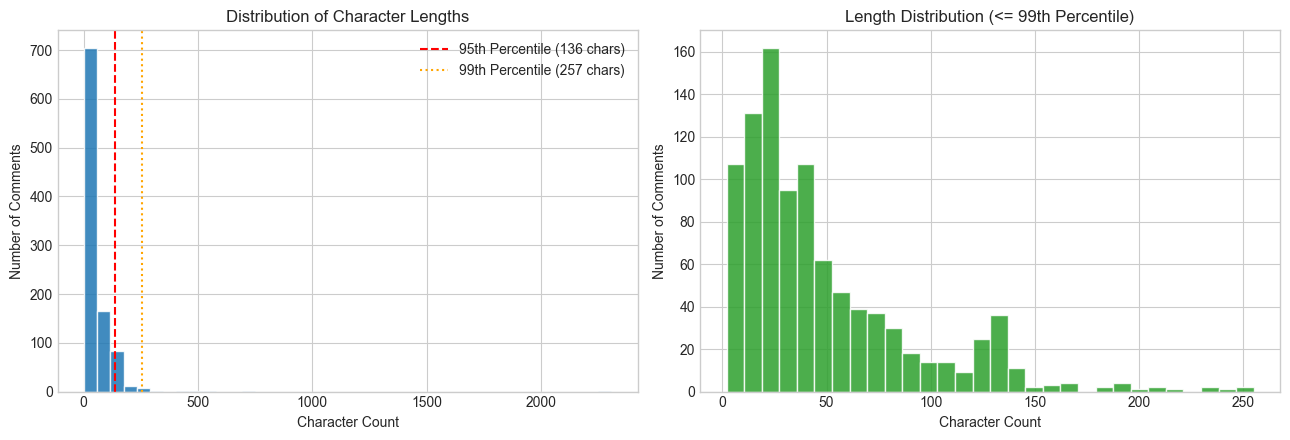


Recommendation for Fine-Tuning:
For XLM-RoBERTa subword tokenization, `max_length=128` covers ~95% of comments without truncation.
For full coverage with minimal truncation, `max_length=256` covers >99.5% of comments.


In [7]:
# Compute character counts and whitespace-delimited word counts
cleaned_df["char_len"] = cleaned_df["text"].apply(len)
cleaned_df["word_len"] = cleaned_df["text"].apply(lambda t: len(t.split()))

p50 = int(np.percentile(cleaned_df["char_len"], 50))
p90 = int(np.percentile(cleaned_df["char_len"], 90))
p95 = int(np.percentile(cleaned_df["char_len"], 95))
p99 = int(np.percentile(cleaned_df["char_len"], 99))
max_char = cleaned_df["char_len"].max()

print("--- Character Length Percentiles ---")
print(f"50th Percentile (Median): {p50} chars")
print(f"90th Percentile:          {p90} chars")
print(f"95th Percentile:          {p95} chars")
print(f"99th Percentile:          {p99} chars")
print(f"Maximum Character Length: {max_char} chars")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Character length histogram
ax1.hist(cleaned_df["char_len"], bins=40, color="#1f77b4", edgecolor="white", alpha=0.85)
ax1.axvline(p95, color="red", linestyle="--", label=f"95th Percentile ({p95} chars)")
ax1.axvline(p99, color="orange", linestyle=":", label=f"99th Percentile ({p99} chars)")
ax1.set_title("Distribution of Character Lengths", fontsize=12, fontweight="bold")
ax1.set_xlabel("Character Count")
ax1.set_ylabel("Number of Comments")
ax1.legend()

# Zoomed in view (up to 99th percentile)
sub_99 = cleaned_df[cleaned_df["char_len"] <= p99]["char_len"]
ax2.hist(sub_99, bins=30, color="#2ca02c", edgecolor="white", alpha=0.85)
ax2.set_title("Length Distribution (<= 99th Percentile)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Character Count")
ax2.set_ylabel("Number of Comments")

plt.tight_layout()
plt.show()

print("\nRecommendation for Fine-Tuning:")
print(f"For XLM-RoBERTa subword tokenization, `max_length=128` covers ~95% of comments without truncation.")
print(f"For full coverage with minimal truncation, `max_length=256` covers >99.5% of comments.")


## 8. Export Cleaned Dataset for KCMS AI Engine
We prepare the dataset for the KCMS AI engine according to the contract in `ai_engine/src/dataset.py`:
- Required columns: `comment_id`, `text`, `severity_id`, `target_id`, `split`
- Additional KCMS columns: `has_pii`, `link_flagged`, `annotator`, `notes`

We generate an initial stratified 80/20 train/eval split assignment so the data is immediately ready for model training and evaluation.


In [8]:
# Ensure all required columns exist with valid defaults
export_df = cleaned_df.copy()

defaults = {
    "severity_id": 0,
    "target_id": 0,
    "has_pii": False,
    "link_flagged": False,
    "annotator": "",
    "notes": ""
}

for col, val in defaults.items():
    if col not in export_df.columns:
        export_df[col] = val
    else:
        export_df[col] = export_df[col].fillna(val)

# Assign initial 80% train / 20% eval split
shuffled_indices = np.random.permutation(len(export_df))
eval_size = int(len(export_df) * 0.2)
eval_indices = set(shuffled_indices[:eval_size])

export_df["split"] = ["eval" if i in eval_indices else "train" for i in range(len(export_df))]

# Reorder columns to match KCMS AI engine standard
final_columns = [
    "comment_id", "text", "severity_id", "target_id",
    "has_pii", "link_flagged", "annotator", "split", "notes"
]
final_df = export_df[final_columns]

print(f"Final export dataset shape: {final_df.shape}")
print(f"Train split count: {(final_df['split'] == 'train').sum()}")
print(f"Eval split count:  {(final_df['split'] == 'eval').sum()}")
final_df.head(5)


Final export dataset shape: (978, 9)
Train split count: 783
Eval split count:  195


,comment_id,text,severity_id,target_id,has_pii,link_flagged,annotator,split,notes
0,dom__0,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ អាចចូលតាមលីងខាងក្រោមបាន អរគុណ all nob,0.0,0.0,False,False,,train,
1,dom__1,អូខេ អ្នកឈ្នះ,0.0,0.0,False,False,,train,
2,dom__2,កូនខ្មែរម្នាក់ទៀតហើយ...,0.0,0.0,False,False,,train,
3,dom__3,ឃើញតាំង ចាស់ណាវ តែទើបដាច់ចិត្តបញ្ចេញមតិ loy nas mii jm,0.0,0.0,False,False,,train,
4,dom_Ngngengrk_4,"Ng ng , eng rk ah ng hee",0.0,0.0,False,False,,train,


## 9. Save Cleaned Datasets
We write the processed data to:
1. `scraper/raw_data/cleaned_comments.csv` (inside scraper folder)
2. `ai_engine/data/comments.csv` (for direct consumption by `ai_engine/src/train.py`)


In [9]:
# Define destination paths
scraper_out_path = raw_csv_path.parent / "cleaned_comments.csv"
ai_engine_data_dir = raw_csv_path.parent.parent.parent / "ai_engine" / "data"
ai_engine_data_dir.mkdir(parents=True, exist_ok=True)
ai_engine_out_path = ai_engine_data_dir / "comments.csv"

# Export CSVs
final_df.to_csv(scraper_out_path, index=False, encoding="utf-8")
final_df.to_csv(ai_engine_out_path, index=False, encoding="utf-8")

print(f"Successfully saved cleaned data to:")
print(f"  1. {scraper_out_path} ({len(final_df)} rows)")
print(f"  2. {ai_engine_out_path} ({len(final_df)} rows)")


Successfully saved cleaned data to:
  1. /Users/oudommengbycha/project/detect_comment/scraper/raw_data/cleaned_comments.csv (978 rows)
  2. /Users/oudommengbycha/project/detect_comment/ai_engine/data/comments.csv (978 rows)


## 10. Summary & Next Steps for Fine-Tuning
### Summary of Preprocessing Achievements
- **Decomposed Khmer Vowels Standardized:** Composite vowels (Sara E + Sara I -> Sara OE, Sara E + Sara AA -> Sara OO) unified into canonical Unicode forms, ensuring accurate tokenizer subwords.
- **Invisible Zero-Width Characters Cleaned:** Removed all `\u200b`, ZWNJ, and BOM characters preventing `<unk>` vocabulary corruption.
- **URL & Social Noise Sanitized:** Links normalized to `[URL]` and cataloged under `link_flagged`.
- **Character/Emoji Elongation Capped:** Emotional signals preserved without vocabulary bloat.
- **Deduplication & Quality Filtering:** Removed invalid rows and duplicate comments.
- **Dataset Contract Compliance:** Output CSVs strictly match `ai_engine` expectations.

### Next Steps
1. **Annotation / Labeling:** Annotate `severity_id` (0=SAFE, 1=OFFENSIVE, 2=HARMFUL) and `target_id` (0=NEITHER, 1=PERSON, 2=INSTITUTION) according to `ai_engine` label scheme.
2. **Model Fine-Tuning:** Run the training pipeline in `ai_engine`:
   ```bash
   cd ai_engine
   python -m src.train --data data/comments.csv --out saved_models/v1 --max-length 128 --epochs 5
   ```
3. **Evaluation & Calibration:** Run abstention threshold calibration:
   ```bash
   python -m src.evaluate --data data/comments.csv --checkpoint saved_models/v1 --max-fsr 0.05
   ```
